### SMOTE (Synthetic Minority OverSampling Technique)

SMOTE is a technique used in ML to address imbalanced datasets where the minority class has signifincantly fewer instances than the majority class. SMOTE involves Generating synthetic instances of the minority class BY INTERPRETING BETWEEN EXISTING INSTANCES.

Issue with Upsmapling

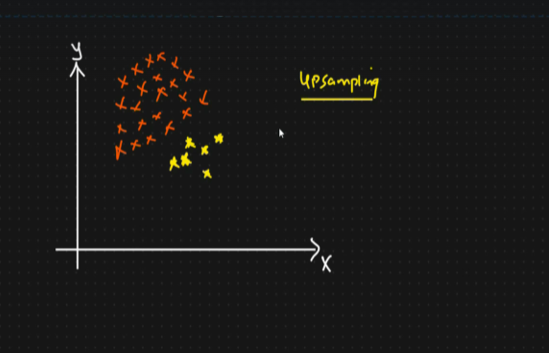

**Problem:** When upsampling the minority class (shown in yellow), synthetic instances are generated only in the vicinity of existing minority class points. This creates several issues:

- **Limited Diversity:** New synthetic data points cluster around existing yellow points, lacking variability across the feature space
- **Poor Generalization:** The model may overfit to the limited regions where minority class samples exist
- **Edge Cases:** The model fails to generalize well to new, unseen instances that fall outside these clustered regions

**Result:** This approach leads to a model with poor predictive performance on cases outside the training minority class distribution.

==> What we need to do is bring more variance to out Scaled Data => Use SMOTE => Join 2 nearest point and create a new data from it => The Data will have variance in it 

In [8]:
from sklearn.datasets import make_classification



In [9]:
# x -> Dependent variable, y -> Independent variable
x,y = make_classification(n_samples=1000,n_redundant=0, n_features=2, n_clusters_per_class=1, weights=[0.90], random_state=12)

In [10]:
import pandas as pd

df1 = pd.DataFrame(x, columns=['f1','f2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1,df2], axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [11]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

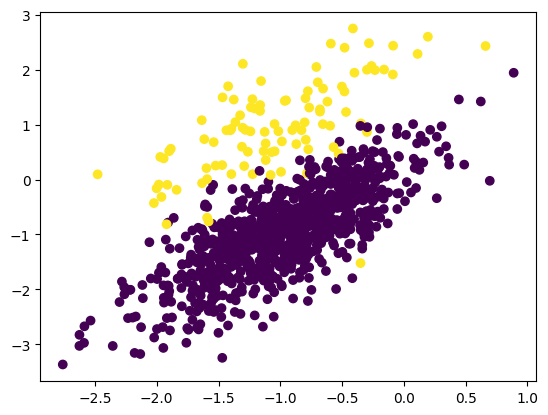

In [12]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])

In [ ]:
### Now use SMOTE to balance the dataset

In [14]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from imblearn.over_sampling import SMOTE

In [19]:
## Transform the dataset using SMOTE
overSample = SMOTE()
x,y = overSample.fit_resample(final_df[['f1', 'f2']], final_df['target'])

In [21]:
x.shape, y.shape

((1800, 2), (1800,))

In [24]:
len(y[y==1])

900

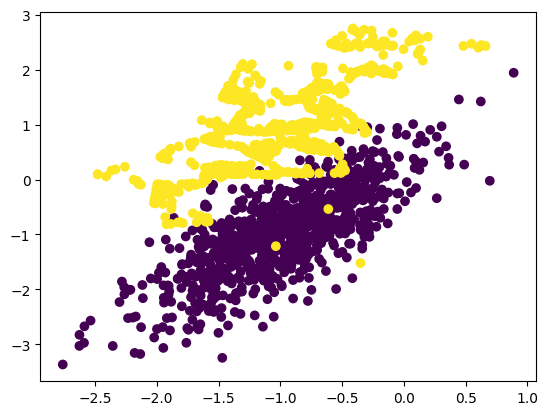

In [25]:
df1 = pd.DataFrame(x, columns=['f1','f2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1,df2], axis=1)
plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])

> Now You can see all the yellow points(minority class) are upScaled and have variance and don't deviate from actual data .